# 🤖 Part 3 · Modelling
### Accenture Project Cycle Datathon — Customer Churn & Retention

Now we build the model that predicts churn, following the arc **baseline → evaluate → tune → stronger model → explain**. We never chase a fancy model first — we get a simple one working, measure it *honestly*, then improve.

### (1) Import libraries and processed data
- `sklearn` — model building, evaluation, and hyperparameter tuning
- `xgboost` — gradient-boosting models (often best on tabular data)
- `shap` — explaining *why* the model made each prediction
- `joblib` — saving trained models
- `os` — creating directories for saved models

> 📘 Full narrated walkthrough: [Info Pack](../INFO_PACK.md#part-3--modelling).

In [1]:
# Import Libraries
import pandas as pd
import numpy as np

import sys
!{sys.executable} -m pip install xgboost
!{sys.executable} -m pip install shap

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import shap
# import joblib
# import os

sns.set_style("whitegrid")

# Import Processed Data
X_train = pd.read_csv("../data/processed_data/X_train.csv")
X_test = pd.read_csv("../data/processed_data/X_test.csv")
y_train = pd.read_csv("../data/processed_data/y_train.csv")
y_test = pd.read_csv("../data/processed_data/y_test.csv")

target_col = "churned_30d"

### (2) Train a baseline model

A **Random Forest** builds many decision trees on random subsets of the data and averages their votes — a strong, forgiving baseline.

Heads-up: the first fit below **fails on purpose**. Random Forests in scikit-learn can't handle raw text columns, a reminder that the encoding from Part 2 isn't optional. Once every categorical column is encoded and the train/test columns are aligned, it fits cleanly. We also pass `class_weight="balanced"` so the model pays proportionally more attention to the rare churners.

In [2]:
X_train.info()

# View the type of output from each variable and count of each type of output
categorical_cols = X_train.select_dtypes(include="object").columns

for col in categorical_cols:
    print(f"\n{col}")
    print(X_train[col].value_counts())

# Check class imbalance
y_train.value_counts()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   user_id              80000 non-null  object
 1   signup_date          80000 non-null  object
 2   plan_tier            80000 non-null  object
 3   company_size         80000 non-null  object
 4   industry             80000 non-null  object
 5   acquisition_channel  80000 non-null  object
 6   is_enterprise        80000 non-null  bool  
 7   downgraded           80000 non-null  int64 
 8   expansion_event      80000 non-null  int64 
 9   region_imputed       80000 non-null  object
dtypes: bool(1), int64(2), object(7)
memory usage: 5.6+ MB

user_id
user_id
8feaab18-4e4b-4280-90cb-c5a2cc2c38a4    1
f2520a23-388f-4c09-a276-f9485b8fb4a1    1
6e2c31bb-e7c7-4198-add5-450241131088    1
b105277a-280f-4c54-9464-46e2781fea96    1
888e440e-2b6f-47e7-8a77-3e2367e1c592    1
                 

churned_30d
0              69631
1              10369
Name: count, dtype: int64

In [ ]:
# Random Forest Baseline Model

# Creates a collection of decision trees - RF trains many trees on many subsets and combines their predictions
rf_model = RandomForestClassifier(
    random_state=42
)

# should fail here > original X_train contains one or more columns with raw text > RF in sklearn can't process strings
rf_model.fit(X_train, y_train.values.ravel())

ValueError: could not convert string to float: '8feaab18-4e4b-4280-90cb-c5a2cc2c38a4'

In [3]:
# Random Forest Baseline Model

# Drop ID column
X_train = X_train.drop(columns=["user_id"])
X_test = X_test.drop(columns=["user_id"])

# Convert signup_date to have a data type of datetime
X_train["signup_date"] = pd.to_datetime(X_train["signup_date"])
X_test["signup_date"] = pd.to_datetime(X_test["signup_date"])

for df in [X_train, X_test]:
    df["signup_year"] = df["signup_date"].dt.year
    df["signup_month"] = df["signup_date"].dt.month
    df["signup_day"] = df["signup_date"].dt.day
    df["signup_dayofweek"] = df["signup_date"].dt.dayofweek

X_train = X_train.drop(columns=["signup_date"])
X_test = X_test.drop(columns=["signup_date"])

# ==========================
# Encode Categorical Variables
# ==========================

# Ordinal Encoding - company_size has a natural ordering
size_map = {
    "1-10": 1,
    "11-50": 2,
    "51-200": 3,
    "200+": 4
}

X_train["company_size"] = X_train["company_size"].map(size_map)
X_test["company_size"] = X_test["company_size"].map(size_map)

# One-Hot Encode nominal categorical variables - no inherent order
categorical_cols = [
    "plan_tier",
    "industry",
    "acquisition_channel",
    "region_imputed"
]

X_train = pd.get_dummies(
    X_train,
    columns=categorical_cols,
    dtype=int
)

X_test = pd.get_dummies(
    X_test,
    columns=categorical_cols,
    dtype=int
)

# Ensure train and test have identical columns
X_train, X_test = X_train.align(
    X_test,
    join="left",
    axis=1,
    fill_value=0
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

print("\nSample encoded columns:")
print(X_train.columns.tolist())

# Creates a collection of decision trees - RF trains many trees on many subsets and combines their predictions
rf_model = RandomForestClassifier(class_weight="balanced", random_state=42)
# rf_model = RandomForestClassifier(
#    random_state=42
# )

rf_model.fit(X_train, y_train.values.ravel())

# Make predictions
y_pred = rf_model.predict(X_test)

# Predict Probabilities
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

Training shape: (80000, 28)
Testing shape: (20000, 28)

Sample encoded columns:
['company_size', 'is_enterprise', 'downgraded', 'expansion_event', 'signup_year', 'signup_month', 'signup_day', 'signup_dayofweek', 'plan_tier_free', 'plan_tier_premium', 'plan_tier_standard', 'industry_education', 'industry_energy', 'industry_finance', 'industry_healthcare', 'industry_manufacturing', 'industry_media', 'industry_retail', 'industry_software', 'industry_telecom', 'industry_transport', 'acquisition_channel_ads', 'acquisition_channel_outbound', 'acquisition_channel_partner', 'acquisition_channel_seo', 'region_imputed_APAC', 'region_imputed_EU', 'region_imputed_LATAM']


### (3) Evaluate the model

This is where most beginners slip, so we do it carefully. **Accuracy alone is a trap** on imbalanced data — if only 5% churn, predicting "nobody churns" scores 95% accuracy and is useless. So we ask better questions:

- **Does it beat random guessing?** → ROC-AUC
- **Are the errors reasonable?** → confusion matrix (false alarms vs missed churners)
- **Does it separate the classes?** → ROC curve
- **What drives predictions?** → feature importance

Key metrics: **Precision** (of those flagged, how many really churned), **Recall** (of real churners, how many we caught), **F1** (their balance), and **ROC-AUC** (class separation across all thresholds). Precision vs recall is a *business* trade-off, set by the cost of a false alarm versus a missed churner.

Accuracy: 0.84935
Precision: 0.18628912071535023
Recall: 0.04822530864197531
F1: 0.07661661048115231
ROC AUC: 0.555396895176618


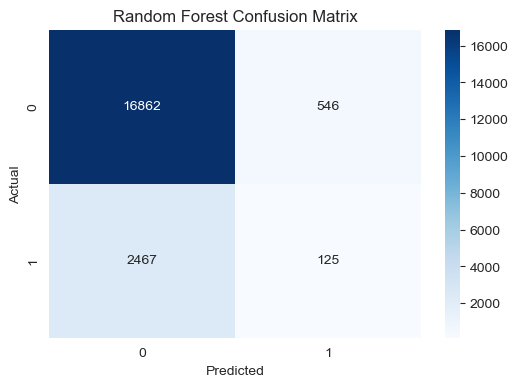

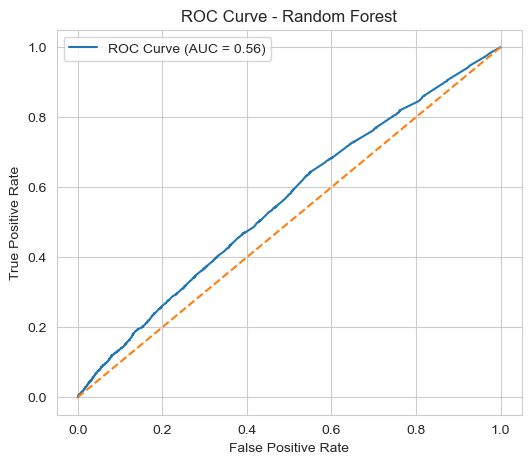

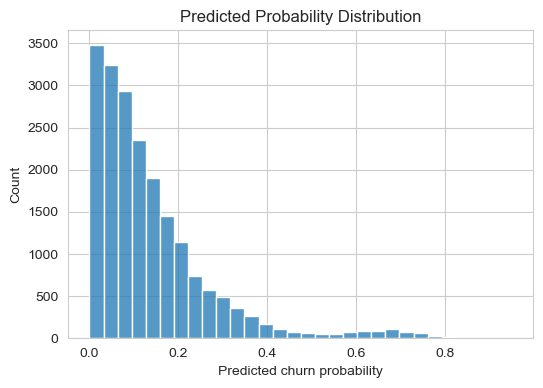

actual
0    0.134806
1    0.160335
Name: pred_proba, dtype: float64


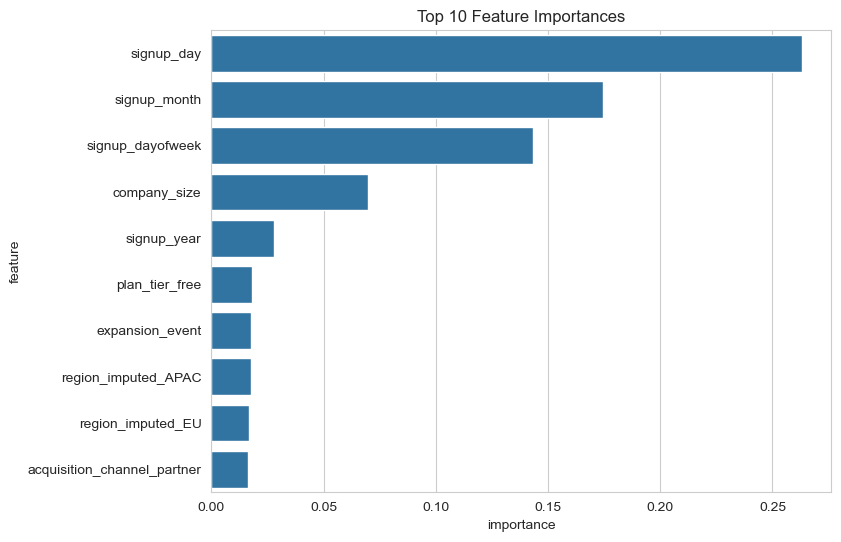

In [4]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    auc,
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
# F1 balances precision and recall
print("F1:", f1_score(y_test, y_pred))
# AUC checks how well results are distinguished from each other
print("ROC AUC:", roc_auc_score(y_test, y_pred_proba))

# Confusion Matrix - ideally large TN, TP and small FP, FN - consider which is more costly
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

# ROC Curve - how well does the model separate churners vs non-churners (visual trade off between recall and precision) 
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

# Prediction Distribution - are predictions confident or uncertain
plt.figure(figsize=(6,4))
sns.histplot(y_pred_proba, bins=30)
plt.title("Predicted Probability Distribution")
plt.xlabel("Predicted churn probability")
plt.ylabel("Count")
plt.show()

# Comparing predicted vs actual churn rate
results_df = pd.DataFrame({
    "actual": y_test.values.ravel(),
    "pred_proba": y_pred_proba
})

print(results_df.groupby("actual")["pred_proba"].mean())

# Feature Importance
importances = rf_model.feature_importances_

feat_imp = pd.DataFrame({
    "feature": X_train.columns,
    "importance": importances
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(data=feat_imp.head(10), x="importance", y="feature")
plt.title("Top 10 Feature Importances")
plt.show()

### (4) Hyperparameter tuning

Every model has dials (**hyperparameters**) controlling how it learns. Instead of guessing, `RandomizedSearchCV` tries random combinations and scores each with **cross-validation** (rotating validation folds). We optimise for **F1** rather than accuracy because of the class imbalance. The comments below explain what each hyperparameter controls.

In [5]:
# n estimators = number of trees (more trees = more stable predictions but slower)
# max depth = how deep each tree grows (less depth = simpler model, less overfitting, deeper = more complex model, can overfit)
# min samples split = minimum samples required to split a node (higher = more conservative trees)
# min samples leaf = minimum samples in final leaf node (prevents tiny overfitted branches)
# max features = how many features each split considers

# random search does
    # 1. pick random hyperparameters
    # 2. build forest
    # 3. do 5-fold cross validation
    # 4. compute F1 score
    # 5. repeat

param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [5, 10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

# Randomised Search - tries a range of random forest settings (e.g. underfit vs overfit) and keeps the best
# larger values = simpler trees, prevents overfitting
rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_grid,
    n_iter=20,
    cv=5,
    scoring="f1",
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train, y_train.values.ravel())

print("Best Parameters:")
print(rf_search.best_params_)

Best Parameters:
{'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}


### (5) Evaluate the tuned model

We take the best estimator from the search and re-evaluate it on the test set exactly as before, comparing it against the untuned baseline via the classification report, ROC-AUC, and feature importances.

              precision    recall  f1-score   support

           0       0.87      0.98      0.92     17408
           1       0.19      0.04      0.06      2592

    accuracy                           0.85     20000
   macro avg       0.53      0.51      0.49     20000
weighted avg       0.78      0.85      0.81     20000

ROC AUC: 0.5590581180569738
                        feature  importance
6                    signup_day    0.292218
5                  signup_month    0.180113
7              signup_dayofweek    0.148404
0                  company_size    0.070773
4                   signup_year    0.025718
25          region_imputed_APAC    0.017052
3               expansion_event    0.016723
26            region_imputed_EU    0.016322
23  acquisition_channel_partner    0.015772
24      acquisition_channel_seo    0.015660


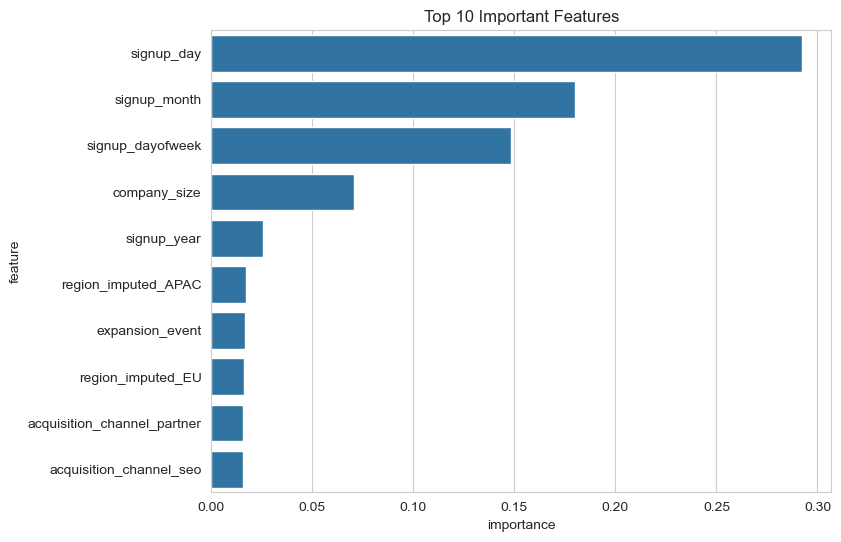

Exception ignored in: <function ResourceTracker.__del__ at 0x104f29da0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x106b39da0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x105c39da0>
Traceback (most recent call last

In [6]:
best_rf = rf_search.best_estimator_

y_pred = best_rf.predict(X_test)
y_pred_proba = best_rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))

# Check performance of tuned vs un-tuned model
print(
    "ROC AUC:",
    roc_auc_score(y_test, y_pred_proba)
)

# Feature Importance - which features helped the most when making decisions
importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": best_rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

print(importance_df.head(10))

# Visual Feature importance_df
plt.figure(figsize=(8,6))

sns.barplot(
    data=importance_df.head(10),
    x="importance",
    y="feature"
)

plt.title("Top 10 Important Features")
plt.show()

### XGBoost — a stronger model

**XGBoost** builds trees *sequentially*, each one correcting the previous tree's mistakes (gradient boosting) — frequently the best performer on tabular data. Two churn-specific techniques appear here:

- **`scale_pos_weight`** scales up the rare churn class so the model can't ignore it.
- **Threshold tuning** — a classifier outputs a *probability*; the `0.5` cut-off is a *choice*, not a law. Lowering it catches more churners (higher recall) at the cost of more false alarms. We use the precision-recall curve to find the threshold that maximises F1.

=== DEFAULT THRESHOLD (0.5) ===
Accuracy: 0.8704
Precision: 0.0
Recall: 0.0
F1: 0.0
=== CUSTOM THRESHOLD (0.2) ===
Accuracy: 0.8326
Precision: 0.17301038062283736
Recall: 0.07716049382716049
F1: 0.10672358591248667


/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


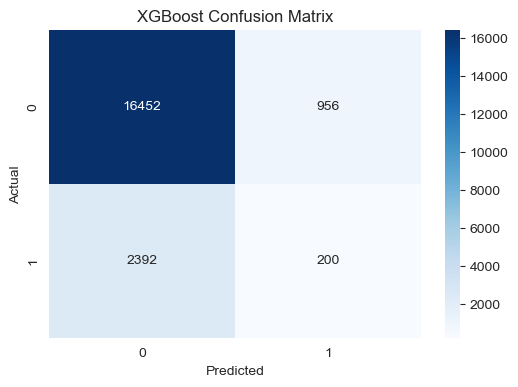

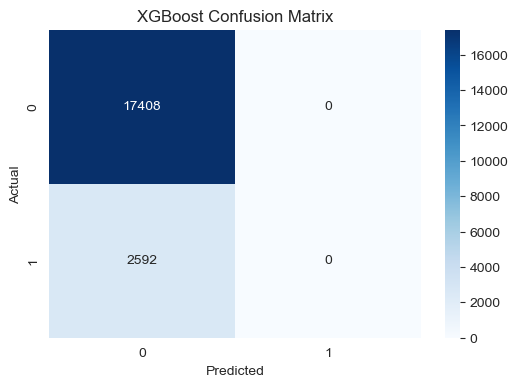

                    feature  importance
8            plan_tier_free    0.290630
9         plan_tier_premium    0.112130
10       plan_tier_standard    0.082376
0              company_size    0.026808
21  acquisition_channel_ads    0.022742
14      industry_healthcare    0.021890
3           expansion_event    0.021694
6                signup_day    0.021683
26        region_imputed_EU    0.021495
5              signup_month    0.021434


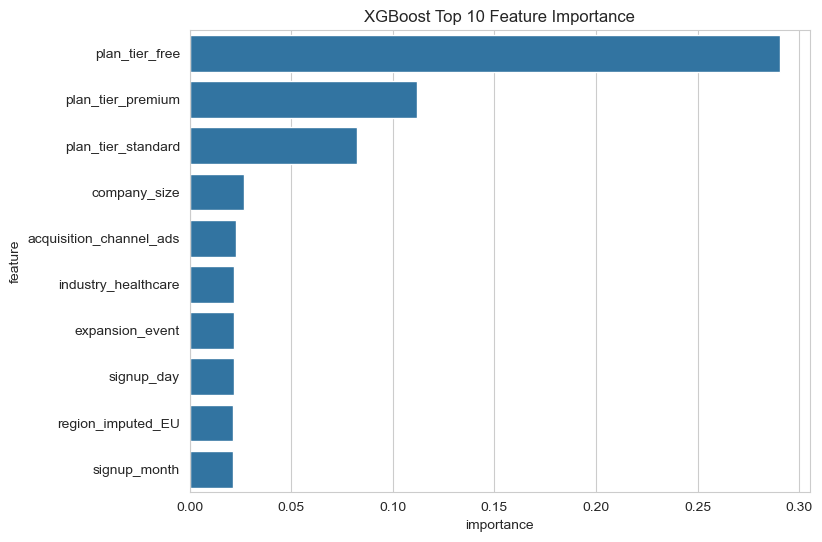

In [13]:
# Train XGBoost Model
import xgboost as xgb

# XGBoost model (baseline)
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

# Fit model
xgb_model.fit(X_train, y_train.values.ravel())

# Predictions
y_pred = xgb_model.predict(X_test)

# Probabilities (for ROC AUC)
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

threshold = 0.2  # try 0.1–0.4 for imbalanced data
y_pred_adjusted = (y_pred_proba >= threshold).astype(int)

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

print("=== DEFAULT THRESHOLD (0.5) ===")

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

print("=== CUSTOM THRESHOLD (0.2) ===")

print("Accuracy:", accuracy_score(y_test, y_pred_adjusted))
print("Precision:", precision_score(y_test, y_pred_adjusted))
print("Recall:", recall_score(y_test, y_pred_adjusted))
print("F1:", f1_score(y_test, y_pred_adjusted))

# Confusion Matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred_adjusted)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")
plt.show()

# ROC Curve
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")
plt.show()

# Feature Importance
import pandas as pd

importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False)

print(importance_df.head(10))

plt.figure(figsize=(8,6))

sns.barplot(
    data=importance_df.head(10),
    x="importance",
    y="feature"
)

plt.title("XGBoost Top 10 Feature Importance")
plt.show()

Fitting 3 folds for each of 30 candidates, totalling 90 fits
              precision    recall  f1-score   support

           0       0.91      0.47      0.62     17408
           1       0.17      0.70      0.27      2592

    accuracy                           0.50     20000
   macro avg       0.54      0.59      0.45     20000
weighted avg       0.82      0.50      0.58     20000

ROC AUC: 0.6000665735315395

Threshold: 0.3
              precision    recall  f1-score   support

           0       0.00      0.00      0.00     17408
           1       0.13      1.00      0.23      2592

    accuracy                           0.13     20000
   macro avg       0.06      0.50      0.11     20000
weighted avg       0.02      0.13      0.03     20000


Threshold: 0.4
              precision    recall  f1-score   support

           0       0.94      0.16      0.28     17408
           1       0.14      0.93      0.25      2592

    accuracy                           0.26     20000
   macr

/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-pa

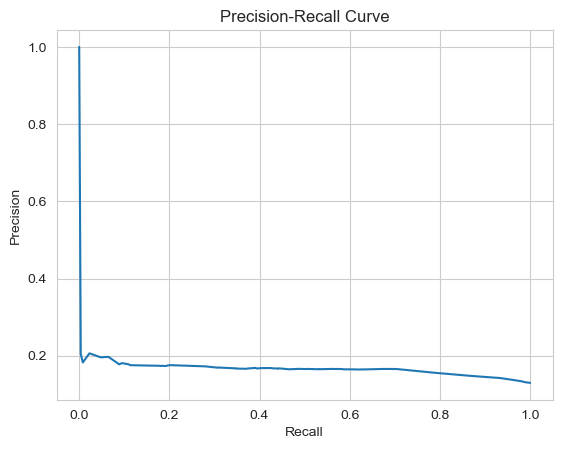

Best threshold: 0.51225406
Best F1: 0.26817613761670217
              precision    recall  f1-score   support

           0       0.91      0.47      0.62     17408
           1       0.17      0.70      0.27      2592

    accuracy                           0.50     20000
   macro avg       0.54      0.59      0.45     20000
weighted avg       0.82      0.50      0.58     20000

ROC AUC: 0.6000665735315395


In [23]:
# Hyperparameter turning
from sklearn.model_selection import RandomizedSearchCV
import xgboost as xgb

xgb_model = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    scale_pos_weight= (y_train.value_counts()[0] / y_train.value_counts()[1])
)

param_grid = {
    "n_estimators": [100, 200, 400, 600],
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 3, 5, 10],
    "gamma": [0, 0.1, 0.2, 0.5]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_grid,
    n_iter=30,
    scoring="roc_auc",
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(X_train, y_train.values.ravel())

# Evaluate Tuned Model
best_xgb = xgb_search.best_estimator_

y_pred_proba = best_xgb.predict_proba(X_test)[:, 1]

# threshold = 0.2
# y_pred = (y_pred_proba >= threshold).astype(int)
y_pred = best_xgb.predict(X_test)

from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_pred_proba))

# Manual Threshold Testing
# choose based on business goal - to catch as many churners as possible, choose a lower threshold, to avoid false alarms etc, choose a higher threshold
for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    y_pred = (y_pred_proba >= t).astype(int)
    print("\nThreshold:", t)
    print(classification_report(y_test, y_pred))

# Visual Threshold Testing
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

# Determine best threshold
f1 = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1])

best_idx = np.nanargmax(f1)

print("Best threshold:", thresholds[best_idx])
print("Best F1:", f1[best_idx])

# Select best XGBoost Model
best_xgb = xgb_search.best_estimator_

y_pred_proba = best_xgb.predict_proba(X_test)[:, 1]

best_threshold = 0.51  # from your PR curve result (or 0.4–0.5)

y_pred_final = (y_pred_proba >= best_threshold).astype(int)

from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

print(classification_report(y_test, y_pred_final))
print("ROC AUC:", roc_auc_score(y_test, y_pred_proba))

cm = confusion_matrix(y_test, y_pred_final)

### SHAP — explaining predictions

A prediction of "this customer will churn" isn't enough — the retention team needs to know **why**, so they can act. **SHAP** assigns each feature a contribution to each individual prediction, giving three lenses:

- **Global** (bar plot) — which features matter most overall
- **Beeswarm** — how high vs low feature values push churn up or down
- **Local** (force plot) — for a single customer, exactly what drove their score

That last view is what lets a retention manager say *"this account is at risk because support tickets are up and usage is down"* — and do something about it.

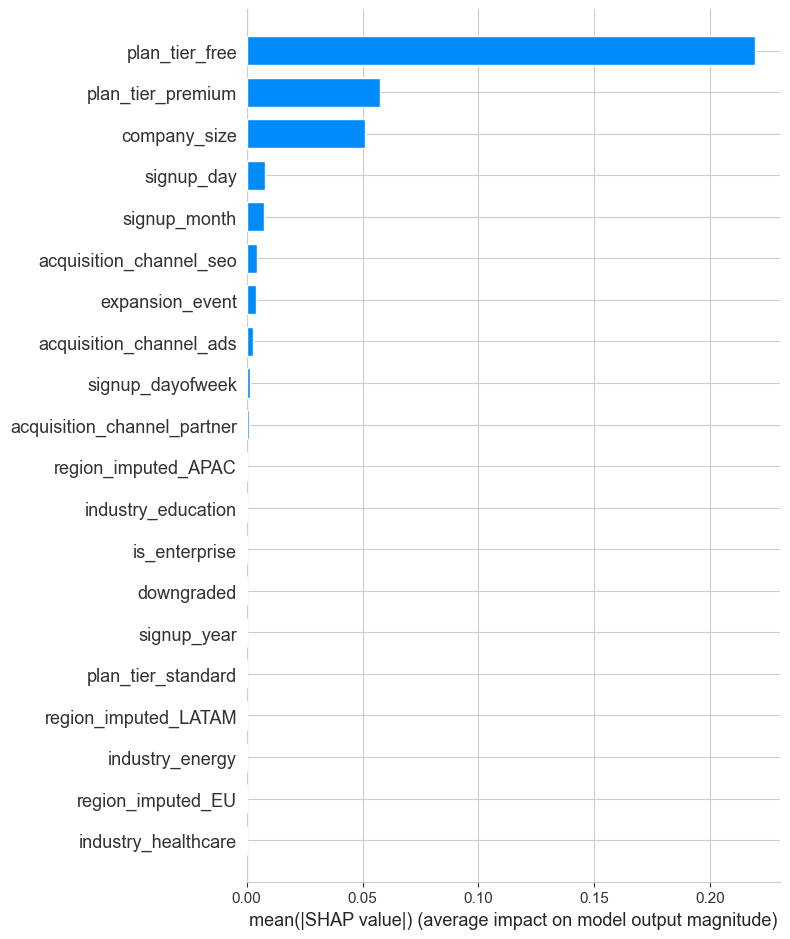

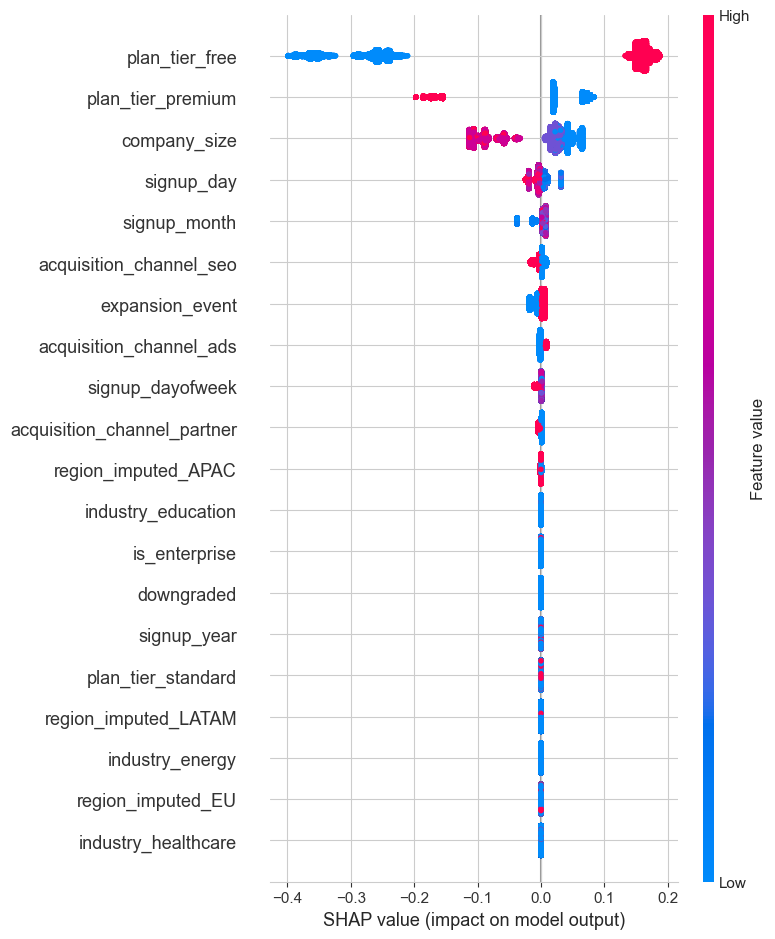

In [22]:
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_train)

# Global Feature Importance
shap.summary_plot(shap_values, X_train, plot_type="bar")

# Beeswarm Plot
shap.summary_plot(shap_values, X_train)

# Single Prediction Explanation
i = 0  # choose any row

shap.initjs()
shap.force_plot(
    explainer.expected_value,
    shap_values[i],
    X_train.iloc[i]
)